In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [2]:
PARQUET_PATH = '../data/chicago_taxi_2024_2026_clean.parquet'

print(f'Loading: {PARQUET_PATH}')
df_2025_clean = pd.read_parquet(PARQUET_PATH)
print(f'Loaded {len(df_2025_clean):,} rows and {df_2025_clean.shape[1]} columns.')
df_2025_clean.head(10)

Loading: ../data/chicago_taxi_2024_2026_clean.parquet
Loaded 14,465,650 rows and 27 columns.


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_flag,dropoff_flag,pickup_ca_centroid_lat,pickup_ca_centroid_lon,dropoff_ca_centroid_lat,dropoff_ca_centroid_lon
0,cd9efc3a2f17e7807815b85da5243858aa220972,c53face33b74e90c719c30c33f394050ca1e93ca6b11a8...,2024-01-07 23:45:00,2024-01-08 00:15:00,2530.0,9.200000,NaN,NaN,3,<NA>,...,41.965813,-87.655876,NaN,NaN,1,0,41.965813,-87.655876,NaN,NaN
1,c24cefb09bac1ecb318b96b59b9a424e460ef29e,2e7f98f477c93ec4c458c0f46cad563cc83e813d5ebc0d...,2024-01-07 23:45:00,2024-01-08 00:15:00,1107.0,14.040000,NaN,NaN,76,22,...,41.980263,-87.913628,41.922760,-87.699158,1,1,41.980263,-87.913628,41.922760,-87.699158
2,b6f5e763d27a57350f8f7e42396d9341d887e203,eb7536e0b280d7842bd4448d3fc93ca078630c2f39f122...,2024-01-07 23:45:00,2024-01-08 00:30:00,3295.0,26.559999,NaN,NaN,76,39,...,41.980263,-87.913628,41.808918,-87.596184,1,1,41.980263,-87.913628,41.808918,-87.596184
3,b6af7c1364cc4c8cf4dbb61f746116682d10b768,cefcf124c1b1156a94b0d3c6edd07763849c63f800638f...,2024-01-07 23:45:00,2024-01-08 00:00:00,660.0,0.200000,NaN,NaN,76,76,...,41.980263,-87.913628,41.980263,-87.913628,1,1,41.980263,-87.913628,41.980263,-87.913628
4,aa07462edd535624bc66e0d91d327370af946c90,d5dc4a704805faed89d18144387c3f5f9150df85c6ea5d...,2024-01-07 23:45:00,2024-01-08 00:00:00,1175.0,16.280001,NaN,NaN,76,28,...,41.980263,-87.913628,41.874004,-87.663521,1,1,41.980263,-87.913628,41.874004,-87.663521
5,9f4391e80166a94c4902ceaf554909203f81cefb,11f73b08790612efe341cf8cf69cadbcb7732293794186...,2024-01-07 23:45:00,2024-01-08 00:00:00,900.0,8.600000,NaN,NaN,33,3,...,41.857185,-87.620331,41.965813,-87.655876,1,1,41.857185,-87.620331,41.965813,-87.655876
6,94768c55269efc39b41551fbd7456ad6a84765f2,6dcd43a953f0c1bdfc49fe8260b9504af2cc45eefdfc22...,2024-01-07 23:45:00,2024-01-08 00:15:00,1212.0,17.820000,NaN,NaN,76,8,...,41.980263,-87.913628,41.899601,-87.633308,1,1,41.980263,-87.913628,41.899601,-87.633308
7,04e40c7d73e387e8516d7e69be774e6cf838447e,6dbac74c2838addb28d0bf34cf126cf1624cc61180bfb2...,2024-01-07 23:45:00,2024-01-08 00:15:00,1741.0,18.370001,1.703198e+10,NaN,76,<NA>,...,41.979073,-87.903038,NaN,NaN,1,0,41.980263,-87.913628,NaN,NaN
8,0ebab4b1c5e7f2c7f9989ac407b12be8f85967e0,761789d686c96d6a313aecc3d5080955d5353b3a7f8d89...,2024-01-07 23:45:00,2024-01-08 00:00:00,1409.0,15.510000,NaN,NaN,76,24,...,41.980263,-87.913628,41.901207,-87.676353,1,1,41.980263,-87.913628,41.901207,-87.676353
9,12ce6337235c0cc1c222858a9d96f723b2ac0524,cf278f6c67e799170264672cf78527e136318d96aefd5f...,2024-01-07 23:45:00,2024-01-07 23:45:00,563.0,4.320000,NaN,NaN,76,76,...,41.980263,-87.913628,41.980263,-87.913628,1,1,41.980263,-87.913628,41.980263,-87.913628


In [3]:
sample_data_df = df_2025_clean.sample(
    n=100_000,
    random_state=42
)

In [4]:
sample_data_df["trip_start_timestamp"] = pd.to_datetime(
    sample_data_df["trip_start_timestamp"]
)

sample_data_df["trip_end_timestamp"] = pd.to_datetime(
    sample_data_df["trip_end_timestamp"]
)


In [5]:
metrics = {
    "Number of trips": sample_data_df["trip_id"].count(),
    "Average trip duration (seconds)": sample_data_df["trip_seconds"].mean(),
    "Average fare per trip": sample_data_df["trip_total"].mean(),
    "Fare per minute": sample_data_df["trip_total"].sum() / (sample_data_df["trip_seconds"].sum() / 60),
    "Total revenue": sample_data_df["trip_total"].sum(),
    "Tips per trip": sample_data_df["tips"].mean(),
    "Average trip distance (miles)": sample_data_df["trip_miles"].mean()
}

metrics_df = pd.DataFrame(metrics.items(), columns=["metric", "value"])
metrics_df

,metric,value
0,Number of trips,1.000000e+05
1,Average trip duration (seconds),1.260717e+03
2,Average fare per trip,2.706892e+01
3,Fare per minute,1.288263e+00
4,Total revenue,2.706892e+06
5,Tips per trip,2.765906e+00
6,Average trip distance (miles),7.112553e+00


In [6]:
df_plot = sample_data_df.copy()

df_plot["trip_minutes"] = df_plot["trip_seconds"] / 60
df_plot["fare_per_minute"] = df_plot["trip_total"] / df_plot["trip_minutes"]

# Optional: remove invalid / extreme values for cleaner plots
df_plot = df_plot[
    (df_plot["trip_seconds"] > 0) &
    (df_plot["trip_total"] >= 0) &
    (df_plot["tips"] >= 0)
].copy()

df_plot = df_plot.replace([float("inf"), -float("inf")], pd.NA)

In [7]:
# Make sure timestamps are datetime
df_plot["trip_start_timestamp"] = pd.to_datetime(df_plot["trip_start_timestamp"])
df_plot["trip_end_timestamp"] = pd.to_datetime(df_plot["trip_end_timestamp"])

# Sort by taxi and start time so "next trip" is meaningful
df_plot = df_plot.sort_values(["taxi_id", "trip_start_timestamp"]).copy()

# Next trip start for the same taxi
df_plot["next_trip_start"] = (
    df_plot
    .groupby("taxi_id")["trip_start_timestamp"]
    .shift(-1)
)

# Idle time between this trip ending and the next trip starting
df_plot["idle_time_seconds"] = (
    df_plot["next_trip_start"] - df_plot["trip_end_timestamp"]
).dt.total_seconds()

# Optional cleaning: remove impossible negative idle times
df_plot.loc[df_plot["idle_time_seconds"] < 0, "idle_time_seconds"] = pd.NA

df_plot["idle_time_minutes"] = df_plot["idle_time_seconds"] / 60

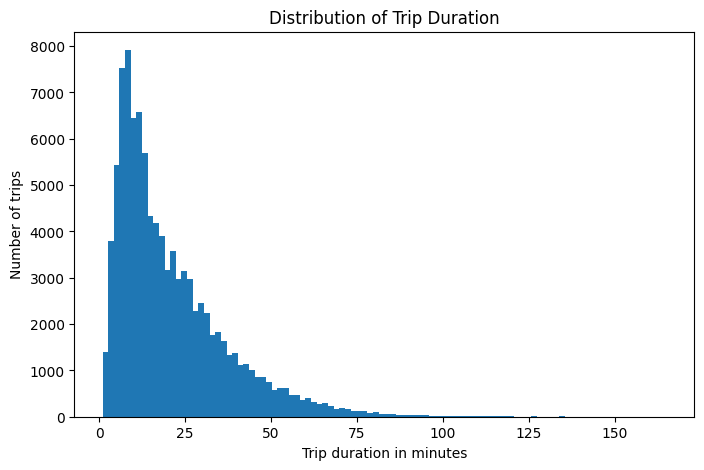

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["trip_minutes"].dropna(), bins=100)
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip duration in minutes")
plt.ylabel("Number of trips")
plt.show()

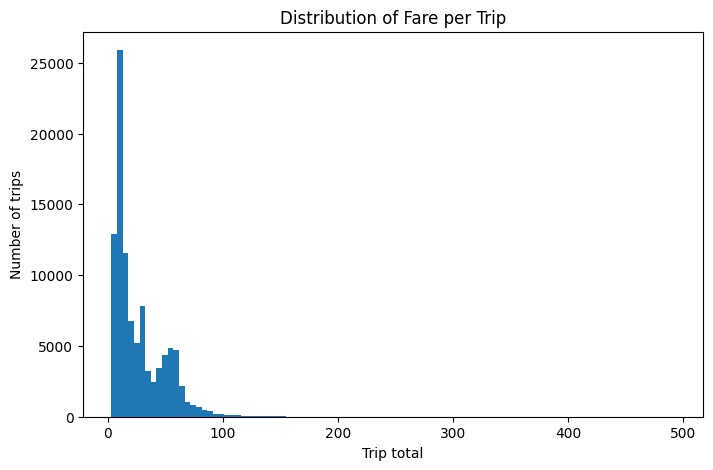

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["trip_total"].dropna(), bins=100)
plt.title("Distribution of Fare per Trip")
plt.xlabel("Trip total")
plt.ylabel("Number of trips")
plt.show()

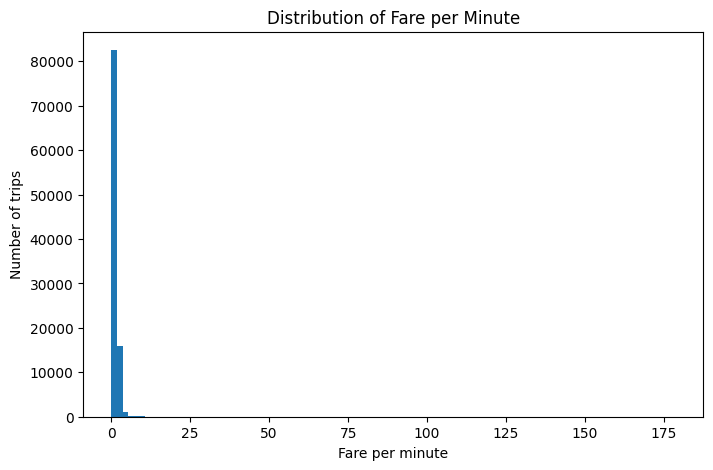

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["fare_per_minute"].dropna(), bins=100)
plt.title("Distribution of Fare per Minute")
plt.xlabel("Fare per minute")
plt.ylabel("Number of trips")
plt.show()

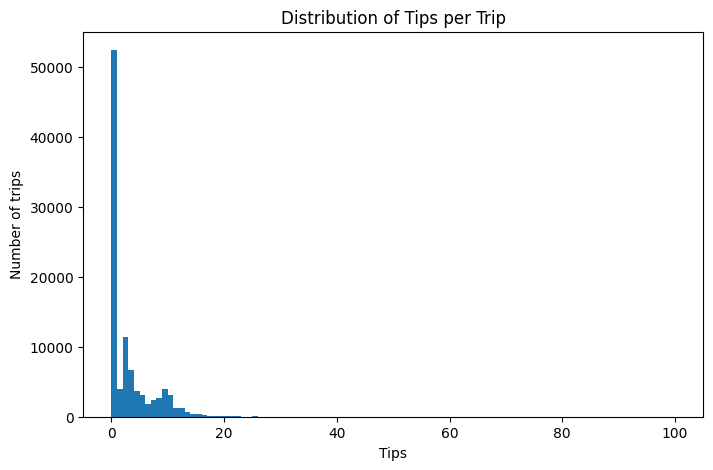

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["tips"].dropna(), bins=100)
plt.title("Distribution of Tips per Trip")
plt.xlabel("Tips")
plt.ylabel("Number of trips")
plt.show()

In [12]:
df_plot["date"] = df_plot["trip_start_timestamp"].dt.date

daily_metrics = (
    df_plot
    .groupby("date")
    .agg(
        number_of_trips=("trip_id", "count"),
        average_trip_duration_seconds=("trip_seconds", "mean"),
        average_fare_per_trip=("trip_total", "mean"),
        total_revenue=("trip_total", "sum"),
        tips_per_trip=("tips", "mean"),
        total_trip_seconds=("trip_seconds", "sum"),
        average_trip_distance_miles=("trip_miles", "mean")
    )
)

daily_metrics["fare_per_minute"] = (
    daily_metrics["total_revenue"] / (daily_metrics["total_trip_seconds"] / 60)
)

daily_metrics.head()

,number_of_trips,average_trip_duration_seconds,average_fare_per_trip,total_revenue,tips_per_trip,total_trip_seconds,average_trip_distance_miles,fare_per_minute
date,,,,,,,,
2024-01-01,61,1334.032837,35.629017,2173.370117,2.884426,81376.0,9.219016,1.602465
2024-01-02,80,1138.300049,29.499500,2359.959961,2.903750,91064.0,7.852250,1.554924
2024-01-03,71,1005.661987,27.900141,1980.910034,2.921972,71402.0,6.970422,1.664584
2024-01-04,75,1006.733337,24.718933,1853.920044,2.078400,75505.0,6.146266,1.473216
2024-01-05,83,1131.542114,26.760721,2221.139893,2.422530,93918.0,7.208313,1.418987


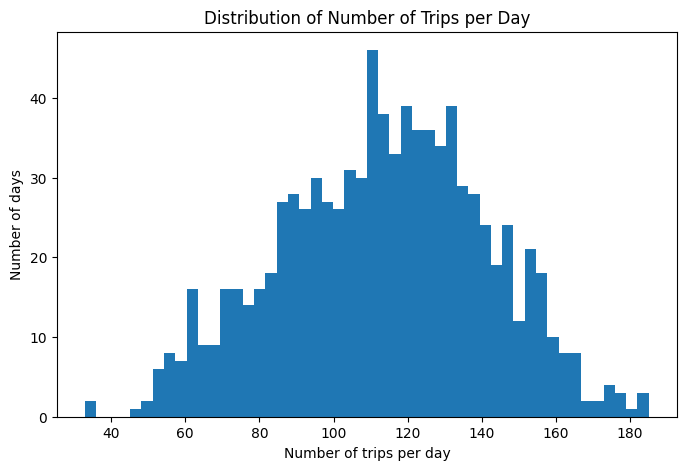

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["number_of_trips"].dropna(), bins=50)
plt.title("Distribution of Number of Trips per Day")
plt.xlabel("Number of trips per day")
plt.ylabel("Number of days")
plt.show()

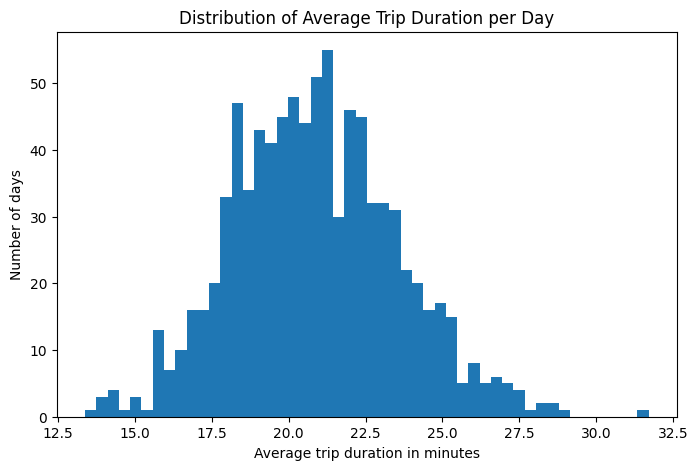

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_trip_duration_seconds"].dropna() / 60, bins=50)
plt.title("Distribution of Average Trip Duration per Day")
plt.xlabel("Average trip duration in minutes")
plt.ylabel("Number of days")
plt.show()

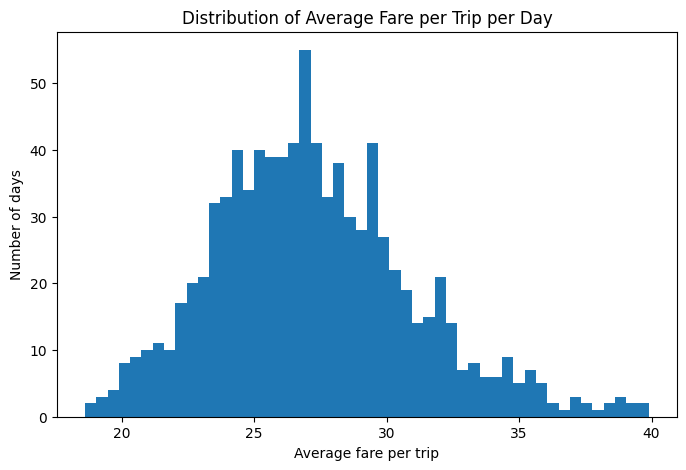

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_fare_per_trip"].dropna(), bins=50)
plt.title("Distribution of Average Fare per Trip per Day")
plt.xlabel("Average fare per trip")
plt.ylabel("Number of days")
plt.show()

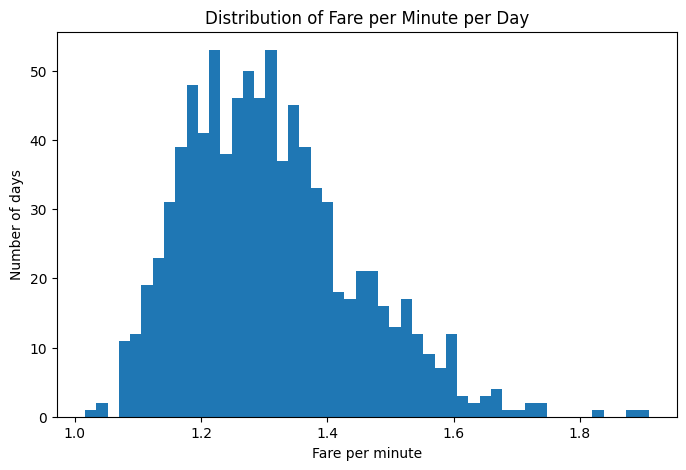

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["fare_per_minute"].dropna(), bins=50)
plt.title("Distribution of Fare per Minute per Day")
plt.xlabel("Fare per minute")
plt.ylabel("Number of days")
plt.show()

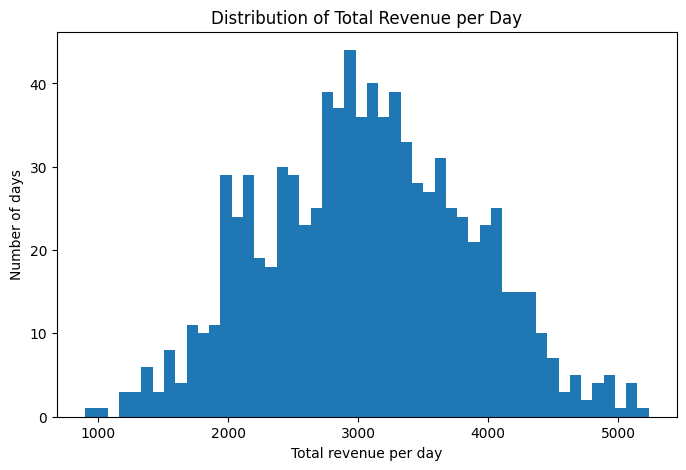

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["total_revenue"].dropna(), bins=50)
plt.title("Distribution of Total Revenue per Day")
plt.xlabel("Total revenue per day")
plt.ylabel("Number of days")
plt.show()

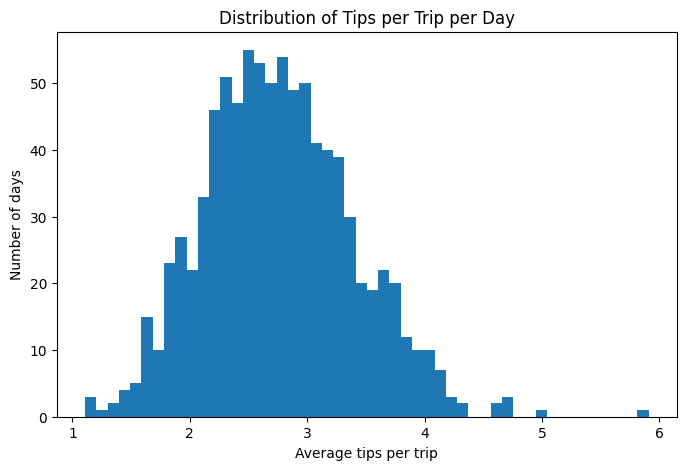

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["tips_per_trip"].dropna(), bins=50)
plt.title("Distribution of Tips per Trip per Day")
plt.xlabel("Average tips per trip")
plt.ylabel("Number of days")
plt.show()

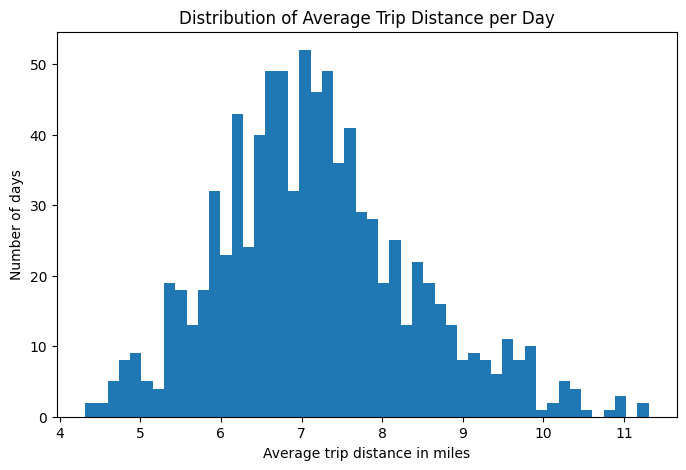

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_trip_distance_miles"].dropna(), bins=50)
plt.title("Distribution of Average Trip Distance per Day")
plt.xlabel("Average trip distance in miles")
plt.ylabel("Number of days")
plt.show()

In [20]:
df_idle = sample_data_df.copy()

df_idle["trip_start_timestamp"] = pd.to_datetime(df_idle["trip_start_timestamp"])
df_idle["trip_end_timestamp"] = pd.to_datetime(df_idle["trip_end_timestamp"])

df_idle = df_idle.sort_values(["taxi_id", "trip_start_timestamp"])

df_idle["next_trip_start"] = (
    df_idle
    .groupby("taxi_id")["trip_start_timestamp"]
    .shift(-1)
)

df_idle["idle_time_minutes"] = (
    df_idle["next_trip_start"] - df_idle["trip_end_timestamp"]
).dt.total_seconds() / 60

df_idle.loc[df_idle["idle_time_minutes"] < 0, "idle_time_minutes"] = pd.NA

In [21]:
idle_time_metric = df_idle["idle_time_minutes"].mean()
idle_time_metric

np.float64(32840.26704774506)

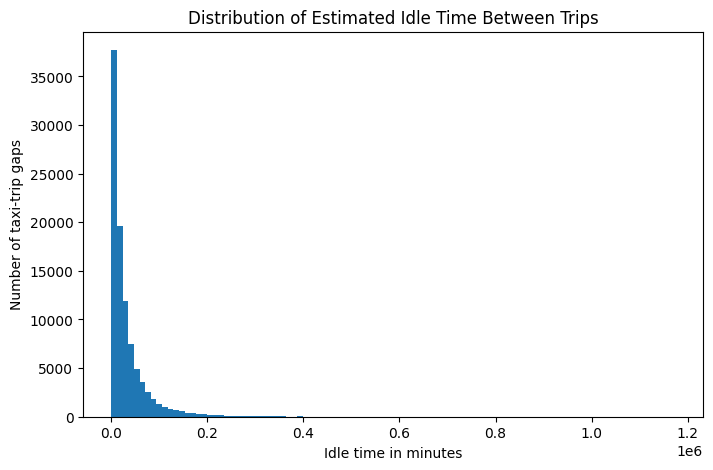

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df_idle["idle_time_minutes"].dropna(), bins=100)
plt.title("Distribution of Estimated Idle Time Between Trips")
plt.xlabel("Idle time in minutes")
plt.ylabel("Number of taxi-trip gaps")
plt.show()